In [5]:
# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import time

# Import library Machine Learning & Feature Extraction
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix
from skimage.feature import hog

# Import library Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Mengunci Random Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)
print("Setup selesai. Random Seed: 42")

Setup selesai. Random Seed: 42


Dimensi X_train: (33600, 784)
Dimensi X_val: (8400, 784)


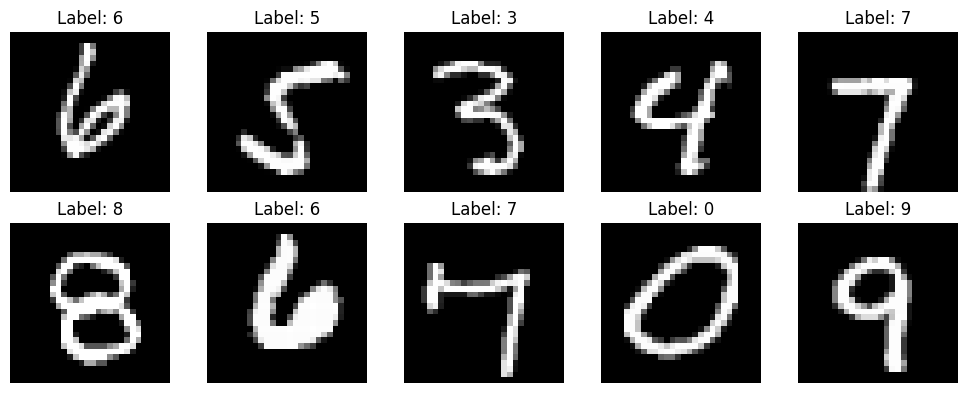

In [6]:
# Load dataset

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Pisahkan fitur (X) dan label (y)
y = train_df['label']
X = train_df.drop('label', axis=1)

# Normalisasi nilai piksel (0 - 255 menjadi 0.0 - 1.0)
X_norm = X / 255.0
test_norm = test_df / 255.0

# Split Data (80% Train, 20% Validation) secara konsisten untuk semua model
X_train, X_val, y_train, y_val = train_test_split(X_norm, y, test_size=0.2, random_state=42)

print(f"Dimensi X_train: {X_train.shape}")
print(f"Dimensi X_val: {X_val.shape}")

# Tampilkan beberapa contoh gambar (EDA)
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    # Ubah array 1D (784,) menjadi gambar 2D (28x28)
    img = X_train.iloc[i].values.reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {y_train.iloc[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# Fungsi ekstraksi fitur HOG untuk 1 batch dataset
def extract_hog_features(data):
    hog_features = []
    for i in range(len(data)):
        img = data.iloc[i].values.reshape((28, 28))
        # Parameter HOG standar untuk gambar 28x28
        fd = hog(img, orientations=9, pixels_per_cell=(8, 8),
                 cells_per_block=(2, 2), visualize=False)
        hog_features.append(fd)
    return np.array(hog_features)

print("Mengekstrak fitur HOG... (Mungkin butuh waktu 1-2 menit)")
X_train_hog = extract_hog_features(X_train)
X_val_hog = extract_hog_features(X_val)

print(f"Dimensi fitur HOG: {X_train_hog.shape[1]} fitur per gambar")

# Inisialisasi dan Training SVM
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

# --- Mencatat Waktu Training SVM ---
start_train = time.time()
svm_model.fit(X_train_hog, y_train)
svm_train_time = time.time() - start_train

# --- Mencatat Waktu Inferensi SVM ---
start_infer = time.time()
svm_preds = svm_model.predict(X_val_hog)
svm_infer_time = time.time() - start_infer

svm_acc = accuracy_score(y_val, svm_preds)
print(f"\n=== Hasil HOG + SVM ===")
print(f"Akurasi: {svm_acc * 100:.2f}%")
print(f"Waktu Training: {svm_train_time:.2f} detik")
print(f"Waktu Inferensi (1 batch): {svm_infer_time:.2f} detik")

Mengekstrak fitur HOG... (Mungkin butuh waktu 1-2 menit)
Dimensi fitur HOG: 144 fitur per gambar

=== Hasil HOG + SVM ===
Akurasi: 96.75%
Waktu Training: 13.15 detik
Waktu Inferensi (1 batch): 13.30 detik


In [8]:
# Menerapkan PCA (mempertahankan 95% variansi gambar)
pca = PCA(n_components=0.95, random_state=42)

# --- Mencatat Waktu Training PCA + RF ---
start_train = time.time()
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_pca, y_train)
rf_train_time = time.time() - start_train

# --- Mencatat Waktu Inferensi PCA + RF ---
start_infer = time.time()
rf_preds = rf_model.predict(X_val_pca)
rf_infer_time = time.time() - start_infer

rf_acc = accuracy_score(y_val, rf_preds)
print(f"=== Hasil PCA + Random Forest ===")
print(f"Dimensi setelah PCA: {X_train_pca.shape[1]} komponen")
print(f"Akurasi: {rf_acc * 100:.2f}%")
print(f"Waktu Training: {rf_train_time:.2f} detik")
print(f"Waktu Inferensi: {rf_infer_time:.2f} detik")

=== Hasil PCA + Random Forest ===
Dimensi setelah PCA: 153 komponen
Akurasi: 93.98%
Waktu Training: 85.87 detik
Waktu Inferensi: 0.17 detik


In [9]:
# CNN membutuhkan input berbentuk image 3D (Tinggi x Lebar x Channel Warna)
X_train_cnn = X_train.values.reshape(-1, 28, 28, 1)
X_val_cnn = X_val.values.reshape(-1, 28, 28, 1)

# Membangun Arsitektur CNN Sederhana
cnn_model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Regularization
    Dense(10, activation='softmax') # 10 kelas (angka 0-9)
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# --- Mencatat Waktu Training CNN ---
print("Memulai Training CNN...")
start_train = time.time()
history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=10, # Cukup 10 epoch untuk baseline
    batch_size=64,
    verbose=1
)
cnn_train_time = time.time() - start_train

# --- Mencatat Waktu Inferensi CNN ---
start_infer = time.time()
cnn_probs = cnn_model.predict(X_val_cnn)
cnn_preds = np.argmax(cnn_probs, axis=1)
cnn_infer_time = time.time() - start_infer

cnn_acc = accuracy_score(y_val, cnn_preds)
print(f"\n=== Hasil CNN ===")
print(f"Akurasi: {cnn_acc * 100:.2f}%")
print(f"Waktu Training: {cnn_train_time:.2f} detik")
print(f"Waktu Inferensi: {cnn_infer_time:.2f} detik")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Memulai Training CNN...
Epoch 1/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9054 - loss: 0.3101 - val_accuracy: 0.9740 - val_loss: 0.0858
Epoch 2/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9686 - loss: 0.1051 - val_accuracy: 0.9819 - val_loss: 0.0558
Epoch 3/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9770 - loss: 0.0750 - val_accuracy: 0.9871 - val_loss: 0.0401
Epoch 4/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9821 - loss: 0.0589 - val_accuracy: 0.9868 - val_loss: 0.0413
Epoch 5/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9841 - loss: 0.0501 - val_accuracy: 0.9883 - val_loss: 0.0368
Epoch 6/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9857 - loss: 0.0435 - val_accuracy: 0.9896 - val_loss: 0.0349
Epoch 7/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9868 - loss: 0.0406 - val_accuracy: 0.9869 - val_loss: 0.0382
Epoch 8/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9894 - loss: 0

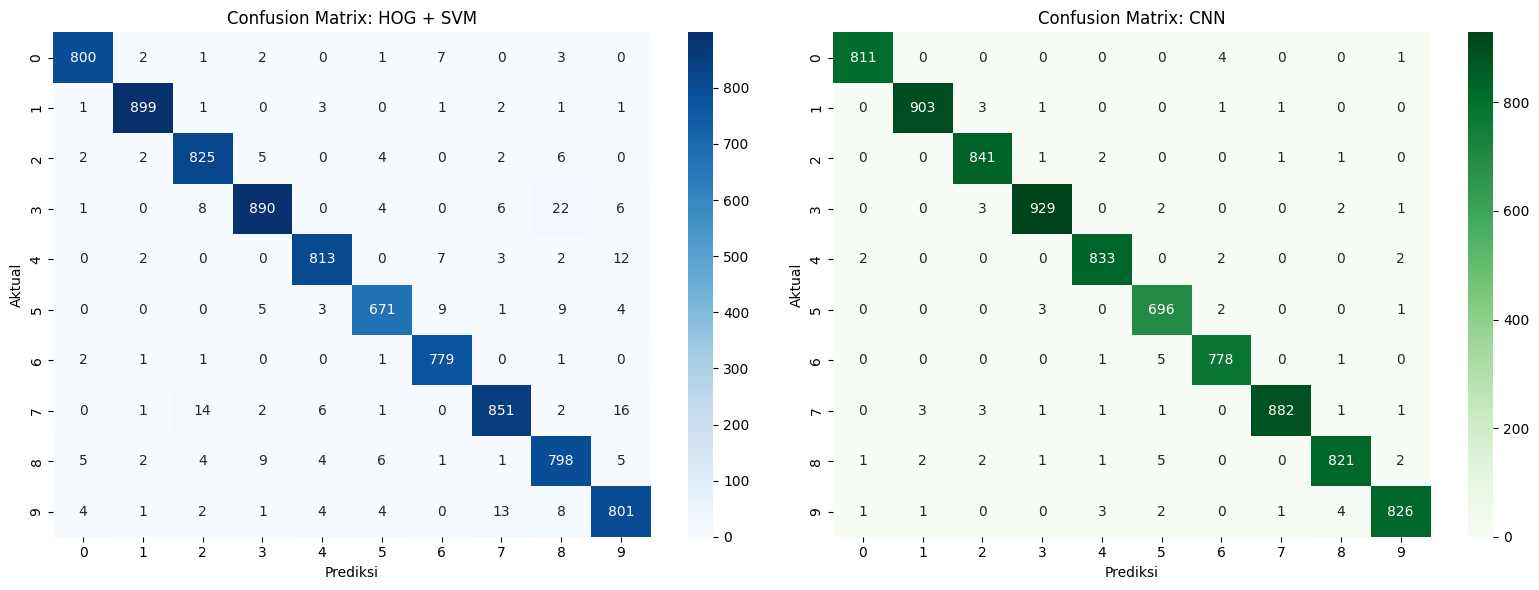

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix HOG + SVM
cm_svm = confusion_matrix(y_val, svm_preds)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: HOG + SVM')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Confusion Matrix CNN
cm_cnn = confusion_matrix(y_val, cnn_preds)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix: CNN')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

Jumlah kesalahan HOG+SVM: 273 gambar
Jumlah kesalahan CNN: 80 gambar


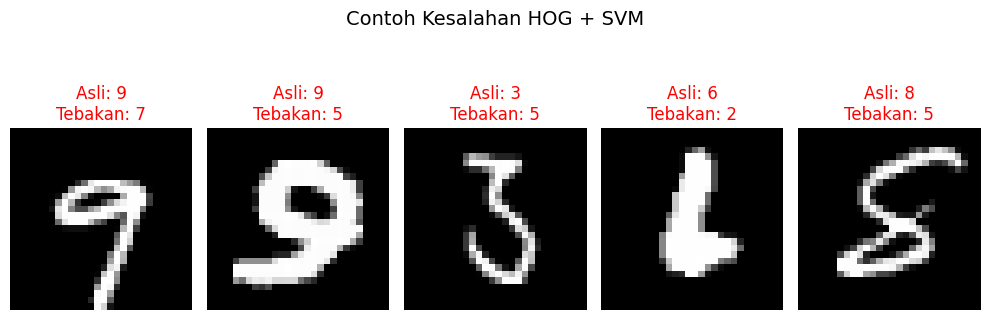

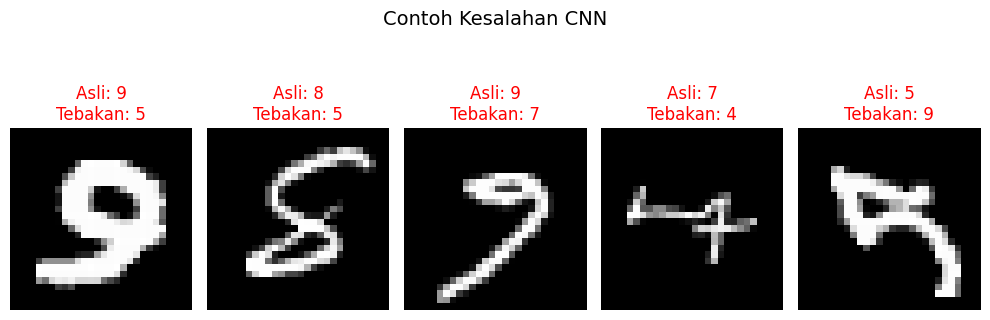

In [11]:
# Mencari index data yang salah diprediksi
errors_svm = np.where(svm_preds != y_val)[0]
errors_cnn = np.where(cnn_preds != y_val)[0]

print(f"Jumlah kesalahan HOG+SVM: {len(errors_svm)} gambar")
print(f"Jumlah kesalahan CNN: {len(errors_cnn)} gambar")

# Fungsi untuk memvisualisasikan gambar yang salah
def plot_misclassified(errors_idx, preds, model_name):
    plt.figure(figsize=(10, 4))
    for i, idx in enumerate(errors_idx[:5]): # Ambil 5 contoh pertama
        plt.subplot(1, 5, i+1)
        img = X_val.iloc[idx].values.reshape(28, 28)
        plt.imshow(img, cmap='gray')
        plt.title(f"Asli: {y_val.iloc[idx]}\nTebakan: {preds[idx]}", color='red')
        plt.axis('off')
    plt.suptitle(f"Contoh Kesalahan {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot kesalahan
plot_misclassified(errors_svm, svm_preds, "HOG + SVM")
plot_misclassified(errors_cnn, cnn_preds, "CNN")

In [12]:
# Mempersiapkan data test
X_test_cnn = test_norm.values.reshape(-1, 28, 28, 1)

# Memprediksi data test
final_preds = np.argmax(cnn_model.predict(X_test_cnn), axis=1)

# Membuat format submission
submission = pd.DataFrame({
    "ImageId": range(1, len(final_preds) + 1),
    "Label": final_preds
})

submission.to_csv('submission_mnist_kasus2.csv', index=False)
print("File 'submission_mnist_kasus2.csv' berhasil dibuat! Silakan upload ke Kaggle.")

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
File 'submission_mnist_kasus2.csv' berhasil dibuat! Silakan upload ke Kaggle.
